# Healthcare Diagnosis Prediction (Multiclass ML)

## Problem Definition
This project predicts patient **Diagnosis** from structured clinical and demographic features.
The task is a **supervised multiclass classification** problem with five classes:
- Hypertension
- Influenza
- Heart Disease
- Cancer
- Diabetes

Practical objective:
- Provide decision support for early triage and diagnostic prioritization (not clinician replacement).

Success criteria:
- Primary metric: **Macro F1** (balanced performance across classes).
- Secondary metrics: Accuracy, Macro Precision, Macro Recall, confusion matrix, and multiclass ROC-AUC.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('AI_in_HealthCare_Dataset.csv')

print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print('Diagnosis classes:', sorted(df['Diagnosis'].unique().tolist()))
df.head()

Shape: 5000 rows x 20 columns
Diagnosis classes: ['Cancer', 'Diabetes', 'Heart Disease', 'Hypertension', 'Influenza']


,Patient_ID,Age,Gender,Blood_Pressure,Heart_Rate,Temperature,Diagnosis,Medication,Treatment_Duration,Insurance_Type,Doctor_Name,Hospital_Name,Lab_Test_Results,X-ray_Results,Surgery_Type,Recovery_Time,Allergies,Family_History,Patient_Satisfaction,AI_Diagnosis_Confidence
0,1,62,Female,102.349134,79.827209,98.912361,Hypertension,Statins,24,Uninsured,Dr. Brown,Children's Hospital,114.906151,Abnormal,Appendectomy,5,Latex,Heart Disease,3,0.917404
1,2,65,Male,137.760933,72.817449,98.912508,Hypertension,Insulin,29,Uninsured,Dr. Wang,Healthcare Clinic,88.556974,Normal,Knee Replacement,2,Shellfish,Diabetes,4,0.811706
2,3,82,Male,97.618564,57.135424,99.189728,Influenza,Chemotherapy,15,Private,Dr. Johnson,Children's Hospital,106.705047,Normal,Gallbladder Removal,7,NaN,Hypertension,2,0.802673
3,4,85,Male,121.743752,67.355838,96.033487,Heart Disease,Chemotherapy,5,Private,Dr. Smith,Healthcare Clinic,83.043268,Normal,Cataract Surgery,7,Latex,Hypertension,5,0.816811
4,5,85,Male,129.530450,64.849416,99.077675,Heart Disease,Insulin,10,Private,Dr. Lee,Children's Hospital,85.543826,Abnormal,Appendectomy,9,Shellfish,Diabetes,1,0.750850


## Exploratory Data Analysis (EDA)
In this section we examine dataset structure, feature types, missingness, class distribution, and relationships among variables to justify preprocessing and model choices.

In [3]:
df.info()

display(df.describe(include='all').T.head(20))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               5000 non-null   int64  
 1   Age                      5000 non-null   int64  
 2   Gender                   5000 non-null   object 
 3   Blood_Pressure           5000 non-null   float64
 4   Heart_Rate               5000 non-null   float64
 5   Temperature              5000 non-null   float64
 6   Diagnosis                5000 non-null   object 
 7   Medication               5000 non-null   object 
 8   Treatment_Duration       5000 non-null   int64  
 9   Insurance_Type           5000 non-null   object 
 10  Doctor_Name              5000 non-null   object 
 11  Hospital_Name            5000 non-null   object 
 12  Lab_Test_Results         5000 non-null   float64
 13  X-ray_Results            5000 non-null   object 
 14  Surgery_Type            

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,5000.0,NaN,NaN,NaN,2500.5,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,NaN,NaN,NaN,53.4332,20.931669,18.0,35.0,53.0,72.0,89.0
Gender,5000,2,Female,2535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood_Pressure,5000.0,NaN,NaN,NaN,119.863621,15.055656,61.940115,109.896065,119.772157,129.893989,168.092063
Heart_Rate,5000.0,NaN,NaN,NaN,74.755327,9.974505,36.760595,67.935319,75.000152,81.556148,117.198456
Temperature,5000.0,NaN,NaN,NaN,98.60371,1.002509,94.930131,97.929791,98.618301,99.265743,102.497318
Diagnosis,5000,5,Heart Disease,1069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medication,5000,5,Aspirin,1021,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Treatment_Duration,5000.0,NaN,NaN,NaN,14.9654,8.403495,1.0,8.0,15.0,22.0,29.0
Insurance_Type,5000,4,Private,1295,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Count
Diagnosis,
Heart Disease,1069
Diabetes,1003
Cancer,1003
Influenza,997
Hypertension,928


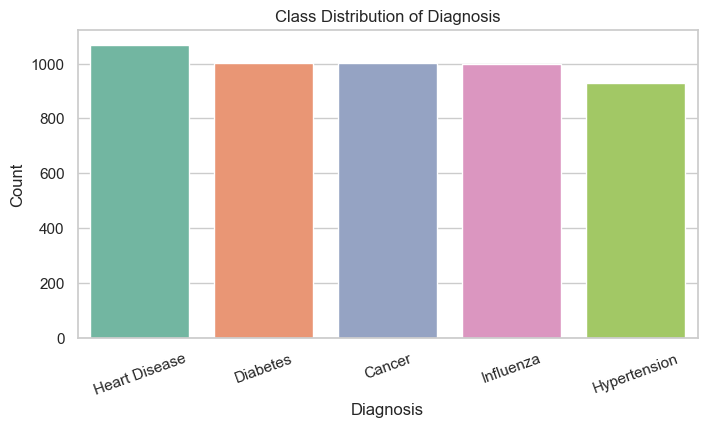

In [4]:
class_counts = df['Diagnosis'].value_counts().sort_values(ascending=False)
display(class_counts.to_frame('Count'))

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Diagnosis', order=class_counts.index, palette='Set2')
plt.title('Class Distribution of Diagnosis')
plt.xticks(rotation=20)
plt.ylabel('Count')
plt.show()

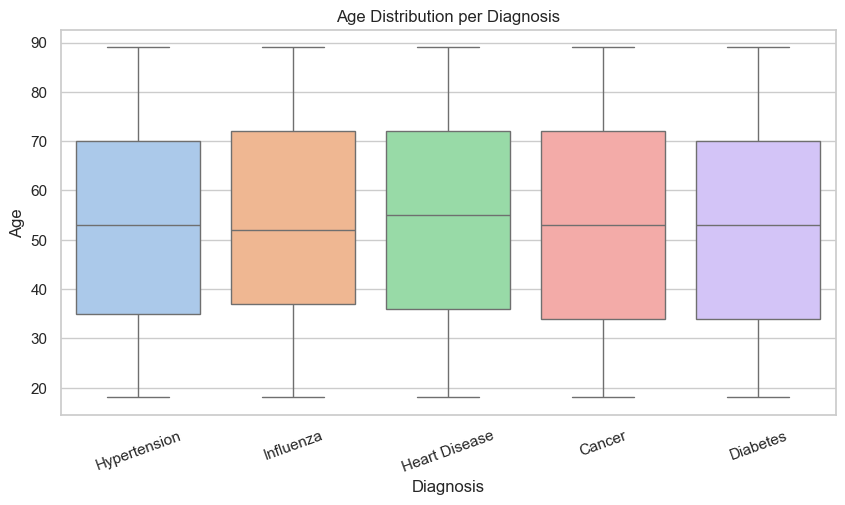

,Age,Blood_Pressure,Heart_Rate,Lab_Test_Results
Diagnosis,,,,
Cancer,53.14,119.73,74.64,99.50
Diabetes,52.91,119.74,74.61,100.51
Heart Disease,54.04,120.13,74.79,100.77
Hypertension,53.51,119.84,74.79,99.81
Influenza,53.54,119.86,74.95,100.35


In [5]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Diagnosis', y='Age', palette='pastel')
plt.title('Age Distribution per Diagnosis')
plt.xticks(rotation=20)
plt.show()

diagnosis_numeric_summary = df.groupby('Diagnosis')[['Age', 'Blood_Pressure', 'Heart_Rate', 'Lab_Test_Results']].mean().round(2)
display(diagnosis_numeric_summary)

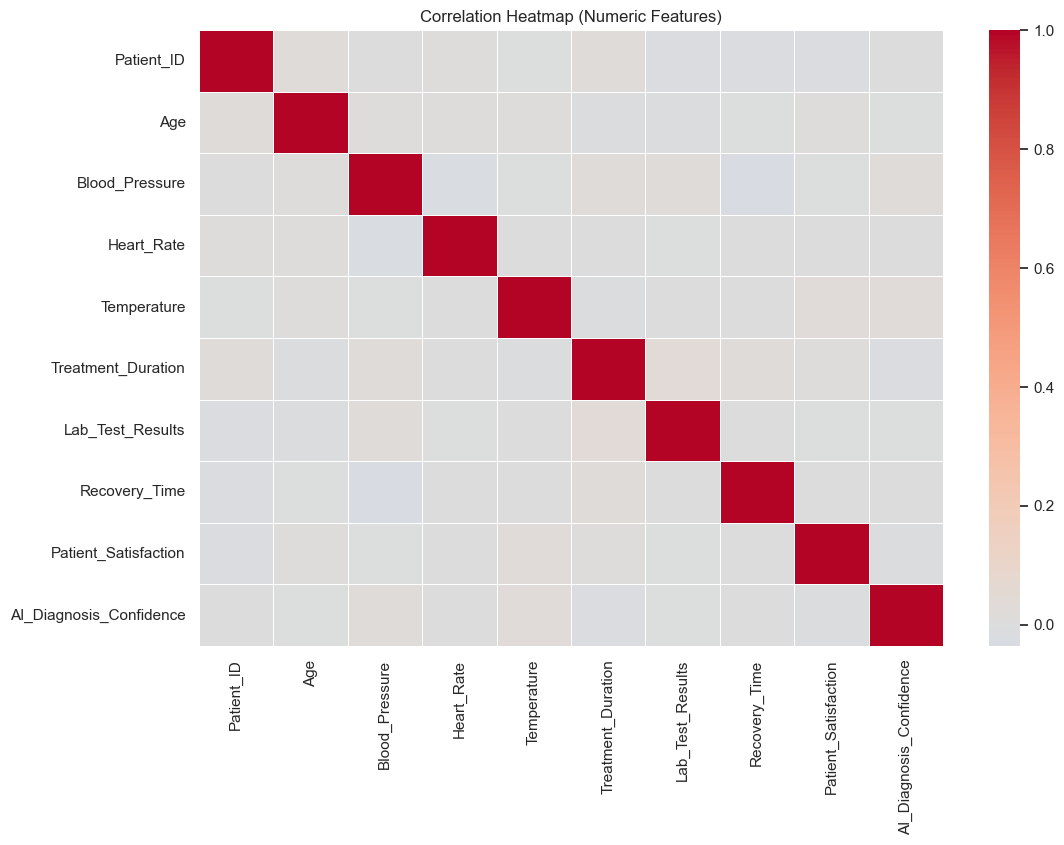

In [6]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

## Preprocessing
Steps:
1. Drop irrelevant columns: `Patient_ID`, `Doctor_Name`, `Hospital_Name`
2. Fill missing values in `Allergies` with `None`
3. Detect and cap outliers in numeric features using IQR clipping
4. Label-encode all categorical feature columns and the target label
5. Stratified train/test split
6. Standardize features with `StandardScaler`

Justification:
- IQR clipping reduces extreme-value distortion while preserving most observations.
- Label encoding is used for compact multiclass modeling in this lab setting.
- Stratification preserves diagnosis proportions in train and test sets.

In [7]:
irrelevant_cols = ['Patient_ID', 'Doctor_Name', 'Hospital_Name']
df_model = df.drop(columns=irrelevant_cols).copy()
df_model['Allergies'] = df_model['Allergies'].fillna('None')

numeric_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
if 'Diagnosis' in numeric_cols:
    numeric_cols.remove('Diagnosis')

outlier_report = []
for col in numeric_cols:
    q1 = df_model[col].quantile(0.25)
    q3 = df_model[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    before = ((df_model[col] < lower) | (df_model[col] > upper)).sum()
    df_model[col] = df_model[col].clip(lower=lower, upper=upper)
    after = ((df_model[col] < lower) | (df_model[col] > upper)).sum()
    outlier_report.append((col, int(before), int(after)))

outlier_df = pd.DataFrame(outlier_report, columns=['Feature', 'Outliers Before', 'Outliers After'])

print('Remaining columns:', len(df_model.columns))
print('Missing values in Allergies:', df_model['Allergies'].isna().sum())
display(outlier_df.head(10))

Remaining columns: 17
Missing values in Allergies: 0


,Feature,Outliers Before,Outliers After
0,Age,0,0
1,Blood_Pressure,49,0
2,Heart_Rate,29,0
3,Temperature,45,0
4,Treatment_Duration,0,0
5,Lab_Test_Results,35,0
6,Recovery_Time,0,0
7,Patient_Satisfaction,0,0
8,AI_Diagnosis_Confidence,0,0


In [8]:
feature_df = df_model.drop(columns=['Diagnosis']).copy()
target_series = df_model['Diagnosis'].copy()

categorical_cols = feature_df.select_dtypes(include=['object']).columns.tolist()
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    feature_df[col] = le.fit_transform(feature_df[col].astype(str))
    encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(target_series)
X = feature_df.copy()
feature_columns = X.columns.tolist()

print('Categorical feature columns encoded:', categorical_cols)
print('Target classes:', target_encoder.classes_.tolist())

Categorical feature columns encoded: ['Gender', 'Medication', 'Insurance_Type', 'X-ray_Results', 'Surgery_Type', 'Allergies', 'Family_History']
Target classes: ['Cancer', 'Diabetes', 'Heart Disease', 'Hypertension', 'Influenza']


In [9]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Train class distribution:', np.bincount(y_train))
print('Test class distribution:', np.bincount(y_test))

Train shape: (4000, 16) | Test shape: (1000, 16)
Train class distribution: [803 802 855 742 798]
Test class distribution: [200 201 214 186 199]


## Model Training
We train three distinct model families with the same split and preprocessing for fair comparison:
- Logistic Regression
- Random Forest
- K-Nearest Neighbors (KNN)

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest (Baseline)': RandomForestClassifier(random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier()
}

predictions = {}
probabilities = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        probabilities[name] = model.predict_proba(X_test)

print('Baseline models trained successfully.')

Baseline models trained successfully.


In [11]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
predictions['Random Forest (Tuned)'] = best_rf.predict(X_test)
probabilities['Random Forest (Tuned)'] = best_rf.predict_proba(X_test)
trained_models['Random Forest (Tuned)'] = best_rf

print('Best Random Forest params:', grid_search.best_params_)
print('Best CV F1-macro:', round(grid_search.best_score_, 4))

Best Random Forest params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1-macro: 0.2027


## Evaluation
For each model we compute:
- Accuracy
- Precision (macro)
- Recall (macro)
- F1-score (macro)
- One-vs-Rest ROC-AUC (macro)

We also inspect confusion matrices, full classification reports, and ROC curves.

Metric interpretation in this healthcare context:
- Macro F1 is primary for balanced performance across all diagnosis classes.
- Recall is important to reduce missed diagnoses.
- ROC-AUC evaluates ranking quality of class probabilities.

In [12]:
metrics_rows = []
reports = {}
y_test_bin = label_binarize(y_test, classes=np.arange(len(target_encoder.classes_)))

for model_name, y_pred in predictions.items():
    row = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision-Macro': precision_score(y_test, y_pred, average='macro'),
        'Recall-Macro': recall_score(y_test, y_pred, average='macro'),
        'F1-Macro': f1_score(y_test, y_pred, average='macro')
    }

    if model_name in probabilities:
        row['ROC-AUC (OvR, Macro)'] = roc_auc_score(
            y_test_bin,
            probabilities[model_name],
            multi_class='ovr',
            average='macro'
        )
    else:
        row['ROC-AUC (OvR, Macro)'] = np.nan

    metrics_rows.append(row)
    reports[model_name] = classification_report(
        y_test, y_pred, target_names=target_encoder.classes_
    )

comparison_df = pd.DataFrame(metrics_rows).sort_values('F1-Macro', ascending=False).reset_index(drop=True)
display(comparison_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision-Macro': '{:.4f}',
    'Recall-Macro': '{:.4f}',
    'F1-Macro': '{:.4f}',
    'ROC-AUC (OvR, Macro)': '{:.4f}'
}))

,Model,Accuracy,Precision-Macro,Recall-Macro,F1-Macro,"ROC-AUC (OvR, Macro)"
0,Random Forest (Baseline),0.2180,0.2170,0.2166,0.2162,0.5174
1,KNN,0.2030,0.1994,0.2012,0.1973,0.4968
2,Logistic Regression,0.2080,0.2012,0.2039,0.1933,0.4954
3,Random Forest (Tuned),0.2010,0.1932,0.1971,0.1894,0.5045


In [13]:
for model_name in comparison_df['Model']:
    print('=' * 90)
    print(f'Classification Report: {model_name}')
    print(reports[model_name])

Classification Report: Random Forest (Baseline)
               precision    recall  f1-score   support

       Cancer       0.20      0.23      0.21       200
     Diabetes       0.20      0.19      0.20       201
Heart Disease       0.26      0.28      0.27       214
 Hypertension       0.21      0.18      0.20       186
    Influenza       0.21      0.20      0.20       199

     accuracy                           0.22      1000
    macro avg       0.22      0.22      0.22      1000
 weighted avg       0.22      0.22      0.22      1000

Classification Report: KNN
               precision    recall  f1-score   support

       Cancer       0.21      0.27      0.23       200
     Diabetes       0.20      0.22      0.21       201
Heart Disease       0.24      0.26      0.25       214
 Hypertension       0.15      0.13      0.14       186
    Influenza       0.20      0.12      0.15       199

     accuracy                           0.20      1000
    macro avg       0.20      0.20      

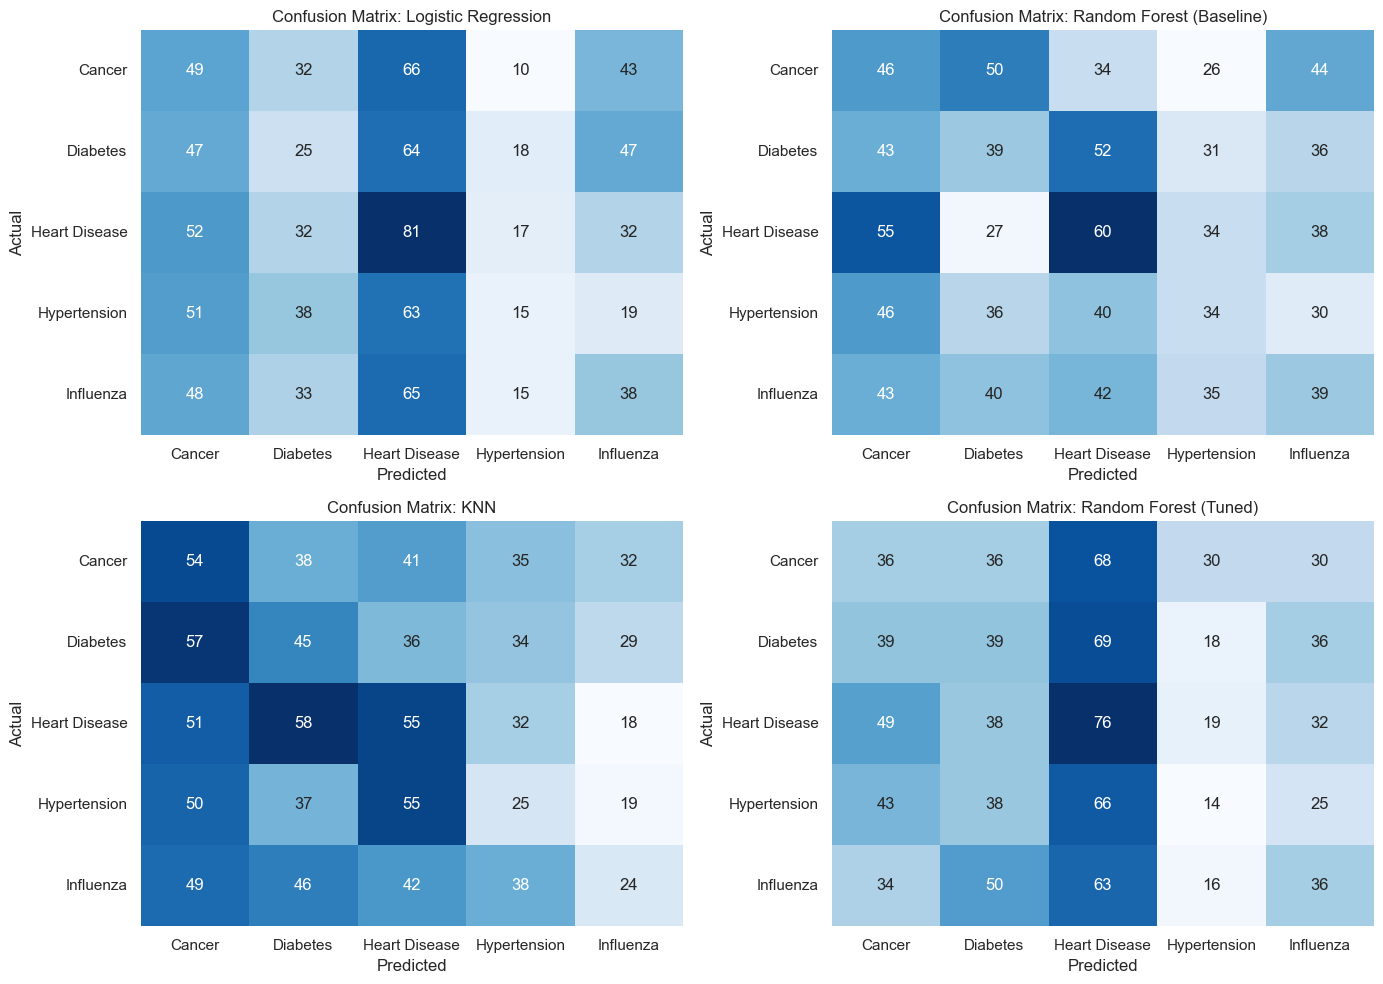

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=target_encoder.classes_,
        yticklabels=target_encoder.classes_,
        ax=axes[idx]
    )
    axes[idx].set_title(f'Confusion Matrix: {model_name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

for j in range(len(predictions), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

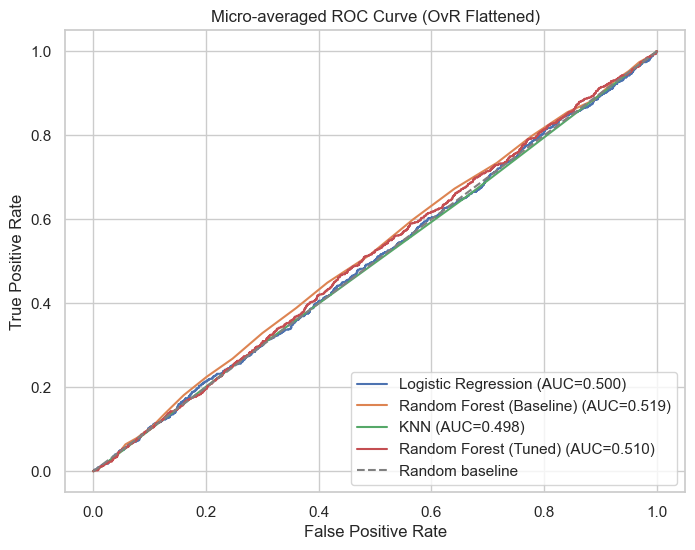

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, probs in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), probs.ravel())
    model_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{model_name} (AUC={model_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
ax.set_title('Micro-averaged ROC Curve (OvR Flattened)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.show()

## Model Selection
Because this is a healthcare use case, we prioritize **macro F1**, **macro recall**, and consistency across classes over raw accuracy alone.

Model trade-offs to discuss in viva:
- Logistic Regression: more interpretable, but may underfit nonlinear patterns.
- Random Forest: captures nonlinear interactions, usually stronger performance, less interpretable.
- KNN: simple and intuitive, but sensitive to scaling and local noise.

In [16]:
best_model_name = comparison_df.loc[0, 'Model']
best_model = trained_models[best_model_name]
best_row = comparison_df.iloc[0]

print(f"Selected model: {best_model_name}")
print(
    "Reason: It provides the strongest macro-level balance for this healthcare multiclass task "
    f"(F1-Macro={best_row['F1-Macro']:.4f}, Recall-Macro={best_row['Recall-Macro']:.4f}, "
    f"ROC-AUC={best_row['ROC-AUC (OvR, Macro)']:.4f})."
)

Selected model: Random Forest (Baseline)
Reason: It provides the strongest macro-level balance for this healthcare multiclass task (F1-Macro=0.2162, Recall-Macro=0.2166, ROC-AUC=0.5174).


## Inference on a New Unseen Patient
We pass a new patient through the same preprocessing (label encoding + scaling) and then predict diagnosis with the selected model.

In [17]:
new_patient = df_model.drop(columns=['Diagnosis']).iloc[[0]].copy()
new_patient.loc[new_patient.index[0], 'Age'] = 55
new_patient.loc[new_patient.index[0], 'AI_Diagnosis_Confidence'] = 0.86
new_patient['Allergies'] = new_patient['Allergies'].fillna('None')

for col, encoder in encoders.items():
    if col in new_patient.columns:
        unknown_values = set(new_patient[col].astype(str)) - set(encoder.classes_)
        if unknown_values:
            raise ValueError(f'Unseen category values in {col}: {unknown_values}')
        new_patient[col] = encoder.transform(new_patient[col].astype(str))

new_patient = new_patient.reindex(columns=feature_columns)
new_patient_scaled = scaler.transform(new_patient)

predicted_idx = best_model.predict(new_patient_scaled)[0]
predicted_label = target_encoder.inverse_transform([predicted_idx])[0]

print('Predicted Diagnosis:', predicted_label)

Predicted Diagnosis: Hypertension


## Interpretation and Insights
Key findings:
- Class distribution is only mildly imbalanced, so macro-averaged metrics are appropriate.
- In this execution, **Random Forest (Baseline)** is selected as the best model by macro F1.
- Confusion matrices show heavy overlap between diagnosis classes, indicating limited separability in the current feature space.
- ROC curves are close to the random baseline, confirming weak discriminative signal.

Next, we inspect feature importance from the selected tree-based model to understand which variables contribute most.

,Feature,Importance
15,AI_Diagnosis_Confidence,0.099876
2,Blood_Pressure,0.098152
3,Heart_Rate,0.097794
4,Temperature,0.097566
8,Lab_Test_Results,0.097094
0,Age,0.087277
6,Treatment_Duration,0.078701
11,Recovery_Time,0.052337
14,Patient_Satisfaction,0.045351
12,Allergies,0.045201


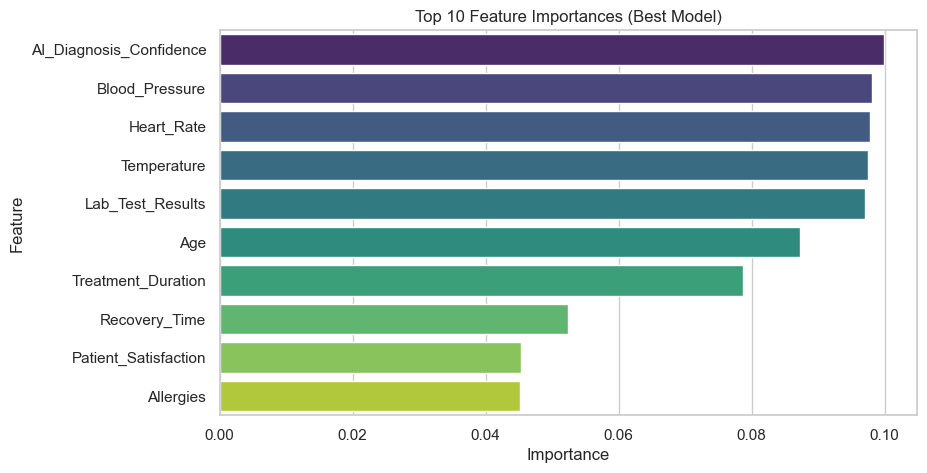

In [18]:
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    display(importance_df.head(10))

    plt.figure(figsize=(9, 5))
    sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
    plt.title('Top 10 Feature Importances (Best Model)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
else:
    print('Selected model does not provide built-in feature_importances_.')

## Limitations and Improvements
Limitations:
- Performance is modest and close to the multiclass chance baseline in several metrics.
- Label encoding may introduce artificial order for categorical variables.
- IQR clipping can suppress potentially informative clinical extremes.
- No external validation cohort was available, limiting generalizability.

Future improvements:
1. Compare label encoding with one-hot encoding and calibrated probability models.
2. Use repeated stratified cross-validation and confidence intervals for robust estimates.
3. Add domain-driven feature engineering (interactions, risk indices, grouped clinical variables).
4. Evaluate on external or temporal holdout data for stronger clinical validity.